## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load 3 CSV data

In [ ]:
ndvi10 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/NDVI_10m.csv")
ndvi20 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/NDVI_20m.csv")
ndvi30 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/NDVI_30m.csv")

metrics = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/03_Python_Analylsis/raw_data/field_metrics.csv")

## Rename NDVI column

In [ ]:
ndvi10 = ndvi10.rename(columns={"mean": "NDVI_10m"})
ndvi20 = ndvi20.rename(columns={"mean": "NDVI_20m"})
ndvi30 = ndvi30.rename(columns={"mean": "NDVI_30m"})

## Select the necessary column

In [ ]:
ndvi10 = ndvi10[['field_id','NDVI_10m']]
ndvi20=ndvi20[['field_id','NDVI_20m']]
ndvi30=ndvi30[['field_id','NDVI_30m']]
metrics = metrics[[
    'field_id',
    'area_m2',
    'shape_inde',
    'core_area',
    'total_area',
    'edge_ratio',
    'size_class'
]]

## Merge Dataset

In [ ]:
ndvi = ndvi10.merge(ndvi20, on="field_id").merge(ndvi30, on="field_id").merge(metrics,on='field_id')

# Create the veriable

## NDVI bias (MAIN RESULT)

In [ ]:
ndvi["bias20"] = ndvi["NDVI_20m"] - ndvi["NDVI_10m"]
ndvi["bias30"] = ndvi["NDVI_30m"] - ndvi["NDVI_10m"]

## absolute error

In [ ]:
ndvi["abs_bias20"] = abs(ndvi["bias20"])
ndvi["abs_bias30"] = abs(ndvi["bias30"])

# CORE ANALYSIS

## Summary

In [ ]:
ndvi[['abs_bias20',
    'abs_bias30']].describe()

,abs_bias20,abs_bias30
count,200.000000,200.000000
mean,0.006366,0.013942
std,0.009441,0.015818
min,0.000009,0.000007
25%,0.001186,0.003511
50%,0.003160,0.008360
75%,0.007647,0.019875
max,0.064149,0.090860


## FIELD SIZE vs ERROR

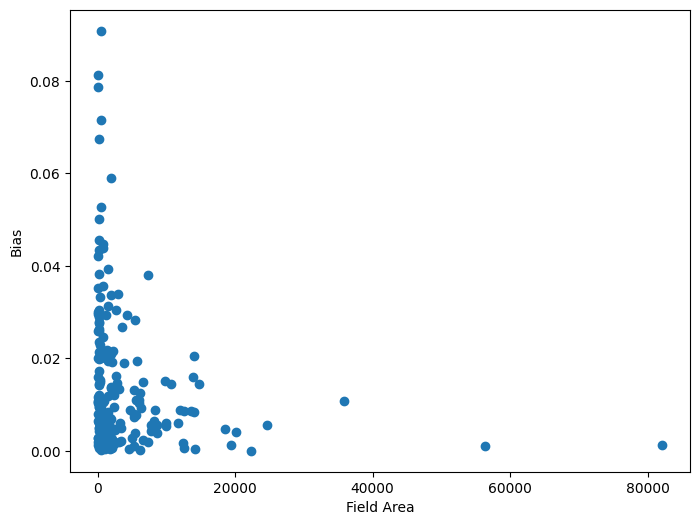

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(

ndvi['area_m2'],
ndvi['abs_bias30']

)


plt.xlabel("Field Area")

plt.ylabel("Bias")


plt.show()


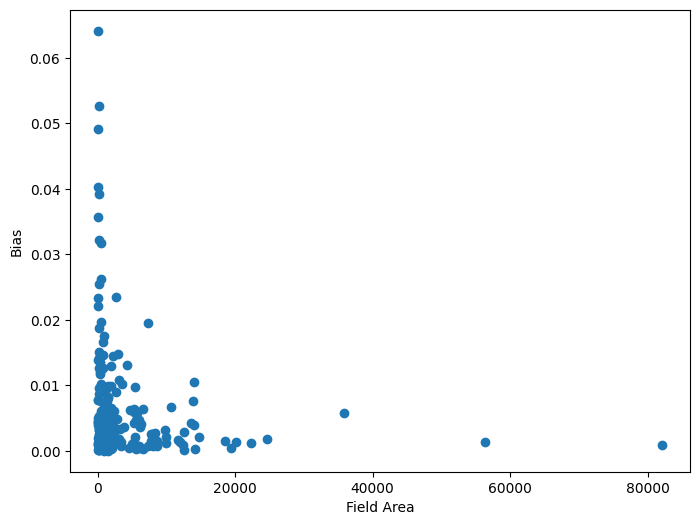

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(

ndvi['area_m2'],
ndvi['abs_bias20']

)


plt.xlabel("Field Area")

plt.ylabel("Bias")


plt.show()

Are smaller fields worse?
    
    yes

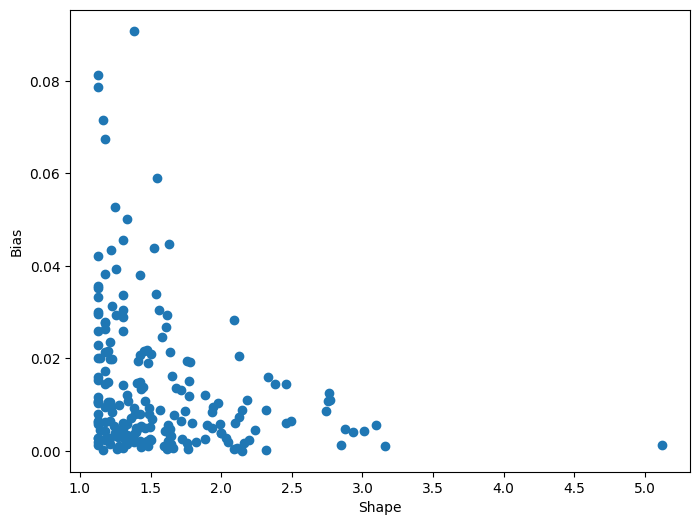

In [ ]:
plt.figure(figsize=(8,6))


plt.scatter(

ndvi['shape_inde'],
ndvi['abs_bias30']

)


plt.xlabel("Shape")


plt.ylabel("Bias")

plt.show()

Do Irregular field suffer more

yes

In [ ]:
corr=ndvi.corr(
numeric_only=True
)

corr['abs_bias30']

,abs_bias30
field_id,-0.030187
NDVI_10m,-0.053006
NDVI_20m,-0.041987
NDVI_30m,-0.029741
area_m2,-0.186555
shape_inde,-0.256056
core_area,-0.181945
total_area,-0.186514
edge_ratio,0.266857
bias20,0.200397


## KEY SCIENTIFIC QUESTION

In [ ]:
threshold = 0.05

stable = ndvi[ndvi["abs_bias30"] < threshold]
print(stable["area_m2"].min())

90.10382570015446


Fields smaller than 90 m² often unstable